In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Input

In [2]:
image_size = 256
batch_size = 32
channels = 3

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "../MRI_DATASET/Training",
    shuffle=True,
    image_size = (image_size,image_size),
    batch_size = batch_size

)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "../MRI_DATASET/Testing",
    shuffle=True,
    image_size = (image_size,image_size),
    batch_size = batch_size

)

Found 6985 files belonging to 4 classes.
Found 2063 files belonging to 4 classes.


In [5]:
# Check the class labels for the training dataset
class_names = train_ds.class_names
print("Class labels:", class_names)

# Alternatively, you can also check the class labels for the test dataset
test_class_names = test_ds.class_names
print("Class labels in test dataset:", test_class_names)

Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class labels in test dataset: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
# Split the training dataset into training and validation sets
train_size = int(0.9 * len(train_ds))
train_img = train_ds.take(train_size)
val_ds = train_ds.skip(train_size)

In [5]:
train_img = train_img.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_img = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [6]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(image_size,image_size),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [8]:
input_shape = (batch_size,image_size,image_size,channels)
n_classes = 4

In [9]:
from keras.applications.xception import Xception

In [10]:
xcp = Xception(input_shape = (256,256,3), weights='imagenet', include_top = False)

In [11]:
for i in xcp.layers:
    i.trainable = False

# Add custom layers on top of Xception

In [12]:
x = Flatten()(xcp.output)
#x = Dense(512, activation='relu')(x)
#x = layers.Dropout(0.5)(x)
#x = Dense(256, activation='relu')(x)
#x = layers.Dropout(0.5)(x)
output = Dense(n_classes, activation='softmax')(x)

In [13]:
# Create the final model
model = models.Model(inputs=xcp.input, outputs=output)

In [14]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
# Print the model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 127, 127, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 127, 127, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 127, 127, 32)         0         ['block1_conv1_bn[0][0]'] 

In [16]:
history = model.fit(
    train_img,
    epochs=5,
    batch_size=batch_size,
    verbose=1,
    validation_data=val_img
)

Epoch 1/5


197/197 [==============================] - 813s 3s/step - loss: 11.0809 - accuracy: 0.7143 - val_loss: 4.8204 - val_accuracy: 0.8546
Epoch 2/5
197/197 [==============================] - 657s 3s/step - loss: 4.3500 - accuracy: 0.8541 - val_loss: 7.5630 - val_accuracy: 0.8062
Epoch 3/5
197/197 [==============================] - 634s 3s/step - loss: 3.3370 - accuracy: 0.8853 - val_loss: 9.4641 - val_accuracy: 0.7988
Epoch 4/5
197/197 [==============================] - 634s 3s/step - loss: 2.2130 - accuracy: 0.9216 - val_loss: 6.5954 - val_accuracy: 0.8502
Epoch 5/5
197/197 [==============================] - 652s 3s/step - loss: 2.5384 - accuracy: 0.9189 - val_loss: 4.8937 - val_accuracy: 0.9016


In [17]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

65/65 [==============================] - 264s 3s/step - loss: 4.9156 - accuracy: 0.8691
Test accuracy: 86.91%


In [18]:
scores = model.evaluate(test_ds)

65/65 [==============================] - 153s 2s/step - loss: 4.9156 - accuracy: 0.8691


In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [20]:
ephocs = 5

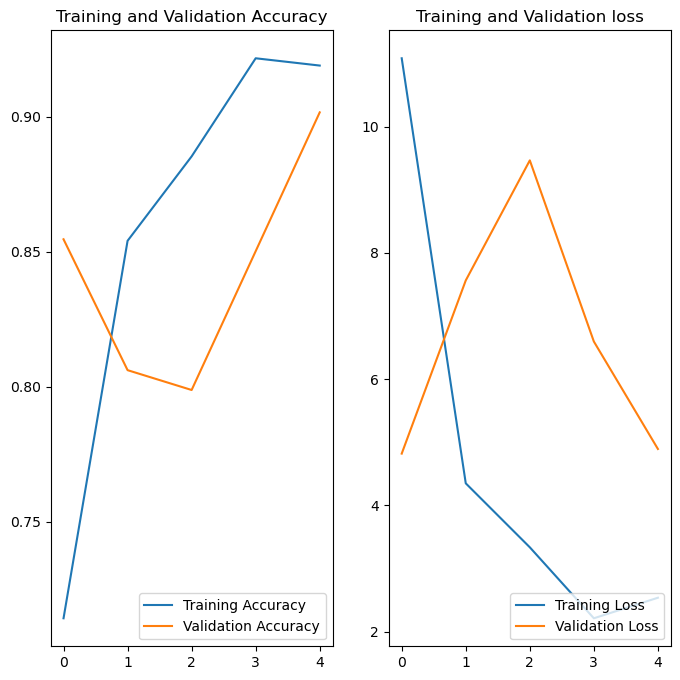

In [21]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(ephocs),acc,label = "Training Accuracy")
plt.plot(range(ephocs),val_acc,label = "Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(ephocs),loss,label = "Training Loss")
plt.plot(range(ephocs),val_loss,label = "Validation Loss")
plt.legend(loc='lower right')
plt.title("Training and Validation loss")

plt.show()

In [25]:
model.save("Xception.h5")

C:\Users\aduser\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
